In [1]:
import maboss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splrep, BSpline
from scipy.special import logit, expit
import numpy.polynomial as poly

In [2]:
def get_TDC_ratio(popstate):
    tcell = 0
    dc = 0
    for population in popstate[1:-1].split(","):
        if len(population) > 2:
            states, pop = population[1:-1].split(":")
            if states != "<nil>":
                list_states = states.split(" -- ")
                try:
                    if "DC" in list_states and "TCell" not in list_states:
                        dc += int(pop)
                    
                    elif "TCell" in list_states:
                        tcell += int(pop)
                except:
                    print(pop)
    return None if (tcell == 0 or dc == 0) else tcell/dc

### Simulation with pyMaBoSS

In [3]:
folder = "ICD_phenomenological/res_icd_1.1"

In [4]:
sim_long = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig.cfg")
res_long = sim_long.run(workdir=folder, prefix="ResICD_phenLong")

In [5]:
sim_long5Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig5CExp.cfg")
res_long5Cl = sim_long5Cl.run(workdir=folder, prefix="ResICD_phenLong5ClExp")

In [6]:
sim_long10Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig10CExp.cfg")
res_long10Cl = sim_long10Cl.run(workdir=folder, prefix="ResICD_phenLong10ClExp")

In [7]:
serie = res_long.get_state_dist_by_index(11*24+1, get_TDC_ratio)
serie5Cl = res_long5Cl.get_state_dist_by_index(11*24+1, get_TDC_ratio)
serie10Cl = res_long10Cl.get_state_dist_by_index(11*24+1, get_TDC_ratio)

<Axes: >

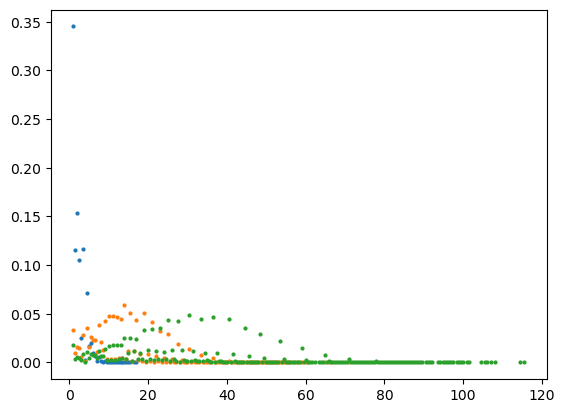

In [8]:
serie.plot(marker='.', linestyle='None', markersize=4, color='C0')
serie5Cl.plot(marker='.', linestyle='None', markersize=4, color='C1')
serie10Cl.plot(marker='.', linestyle='None', markersize=4, color='C2')

In [9]:
c = poly.Polynomial.fit(serie.index[1:], logit(serie.values[1:]), deg=3)
c5Cl = poly.Polynomial.fit(serie5Cl.index[1:], logit(serie5Cl.values[1:]), deg=3)
c10Cl = poly.Polynomial.fit(serie10Cl.index[1:], logit(serie10Cl.values[1:]), deg=3)

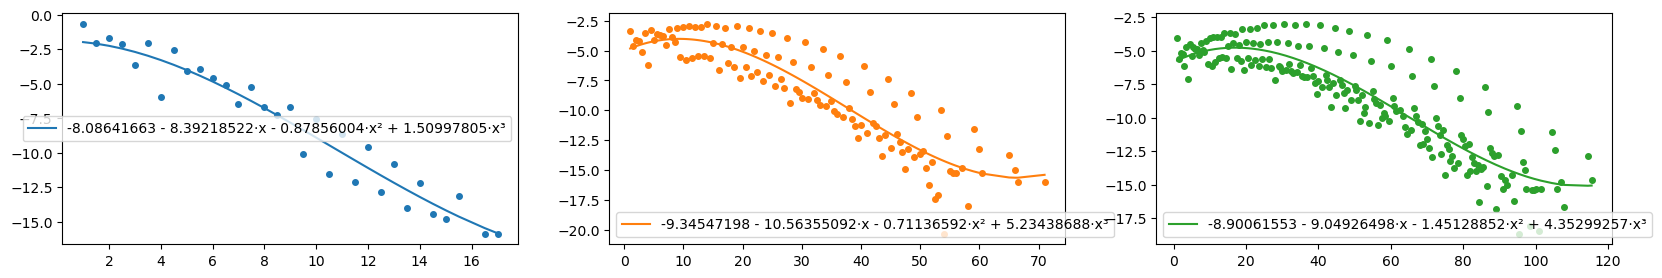

In [10]:
fig, ax = plt.subplots(1,3, figsize=(20,3))
ax[0].plot(serie.index, logit(serie.values), marker='o', markersize=4, color='C0', linestyle='None')
ax[0].plot(serie.index,  c(serie.index), marker=None, color='C0', linestyle='-', label=str(c))
ax[0].legend()

ax[1].plot(serie5Cl.index, logit(serie5Cl.values), marker='o', markersize=4, color='C1', linestyle='None')
ax[1].plot(serie5Cl.index, c5Cl(serie5Cl.index), marker=None, color='C1', linestyle='-', label=str(c5Cl))
ax[1].legend()

ax[2].plot(serie10Cl.index, logit(serie10Cl.values), marker='o', markersize=4, color='C2', linestyle='None')
ax[2].plot(serie10Cl.index, c10Cl(serie10Cl.index), marker=None, color='C2', linestyle='-', label=str(c10Cl))
ax[2].legend()

In [11]:
exp_data = pd.read_csv("ICD_phenomenological/TratioDC.csv", sep="\t")
exp_data_filtered = exp_data[(exp_data["Day"] == 11) & (exp_data["Treatment"] == "MTX")]["TratioDC"]

In [12]:
log_likelyhood = np.log(np.prod(expit(c(exp_data_filtered))))
log_likelyhood5Cl = np.log(np.prod(expit(c5Cl(exp_data_filtered))))
log_likelyhood10Cl = np.log(np.prod(expit(c10Cl(exp_data_filtered))))

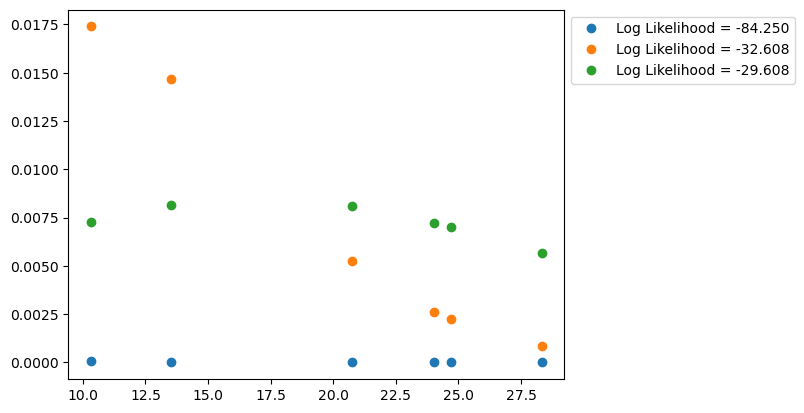

In [13]:
plt.plot(exp_data_filtered.values, expit(c(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood))
plt.plot(exp_data_filtered.values, expit(c5Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood5Cl))
plt.plot(exp_data_filtered.values, expit(c10Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood10Cl))
plt.legend(loc='upper left', bbox_to_anchor=(1., 1.))